In [11]:
import os
from urllib.parse import urljoin
from bs4 import BeautifulSoup
import pandas as pd
import requests

GET_DATA_URL = "https://insideairbnb.com/get-the-data/"
OUTPUT_DIR = "data/asheville_airbnb"
HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}


def get_asheville_download_links():
    """Scrapes Inside Airbnb's data page to extract current Asheville file links."""
    print("Fetching Inside Airbnb data catalog...")
    response = requests.get(GET_DATA_URL, headers=HEADERS)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")
    links = {}

    # Locate all anchor tags containing asheville download URLs
    for a in soup.find_all("a", href=True):
        href = a["href"]
        if "asheville" in href.lower() and (
            href.endswith(".csv.gz")
            or href.endswith(".csv")
            or href.endswith(".geojson")
        ):
            filename = href.split("/")[-1]
            # Ensure full qualified URL
            full_url = urljoin(GET_DATA_URL, href)
            # Store the latest version discovered
            links[filename] = full_url

    return links


def download_file(url: str, output_path: str):
    """Streams a remote file to disk in chunks."""
    print(f"Downloading {os.path.basename(output_path)}...")
    with requests.get(url, headers=HEADERS, stream=True) as r:
        r.raise_for_status()
        with open(output_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)


def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    links = get_asheville_download_links()
    if not links:
        print("No direct download links found for Asheville.")
        return

    print(f"Found {len(links)} available dataset files for Asheville:")
    for fname, url in links.items():
        print(f" - {fname}: {url}")

    # 1. Download all files into the local folder
    for fname, url in links.items():
        dest = os.path.join(OUTPUT_DIR, fname)
        if not os.path.exists(dest):
            download_file(url, dest)
        else:
            print(f"File {fname} already exists locally. Skipping download.")

    # 2. Quick Ingestion Example: Load the Detailed Listings file into Pandas
    # Pandas handles .csv.gz automatically with compression='gzip'
    listings_gz_path = os.path.join(OUTPUT_DIR, "listings.csv.gz")
    if os.path.exists(listings_gz_path):
        print("\nLoading detailed listings into DataFrame...")
        df_listings = pd.read_csv(listings_gz_path, compression="gzip", low_memory=False)
        print(f"Loaded {len(df_listings)} listings across {len(df_listings.columns)} features.")
        print(df_listings[["id", "name", "room_type", "price", "review_scores_rating"]].head())


if __name__ == "__main__":
    main()

Fetching Inside Airbnb data catalog...
Found 7 available dataset files for Asheville:
 - listings.csv.gz: https://data.insideairbnb.com/united-states/nc/asheville/2026-06-25/data/listings.csv.gz
 - calendar.csv.gz: https://data.insideairbnb.com/united-states/nc/asheville/2026-06-25/data/calendar.csv.gz
 - reviews.csv.gz: https://data.insideairbnb.com/united-states/nc/asheville/2026-06-25/data/reviews.csv.gz
 - listings.csv: https://data.insideairbnb.com/united-states/nc/asheville/2026-06-25/visualisations/listings.csv
 - reviews.csv: https://data.insideairbnb.com/united-states/nc/asheville/2026-06-25/visualisations/reviews.csv
 - neighbourhoods.csv: https://data.insideairbnb.com/united-states/nc/asheville/2026-06-25/visualisations/neighbourhoods.csv
 - neighbourhoods.geojson: https://data.insideairbnb.com/united-states/nc/asheville/2026-06-25/visualisations/neighbourhoods.geojson
File listings.csv.gz already exists locally. Skipping download.
File calendar.csv.gz already exists locally

Loading Asheville detailed listings dataset...
Initial dimensions: 2865 rows, 90 columns

--- Cleaning Data ---
Non-null price values found: 2616 / 2865
Dropped 259 pricing anomaly/null records.
Remaining valid rows for analysis: 2606
Cleaned data successfully saved to: data/cleaned\asheville_listings_cleaned.csv

--- Exploratory Data Analysis ---

=== Room Type Summary ===
      room_type  listing_count  median_price  mean_price  avg_rating
Entire home/apt           2364        236.55  302.005935    4.900939
     Hotel room              2        179.00  179.000000    4.540000
   Private room            232        113.75  152.836078    4.876422
    Shared room              8         55.50   50.750000    4.842500

=== Top 10 Neighborhoods by Volume ===
 neighbourhood_cleansed  total_listings  median_price
                  28806             692       201.495
                  28801             587       224.000
                  28803             404       257.680
                  2880

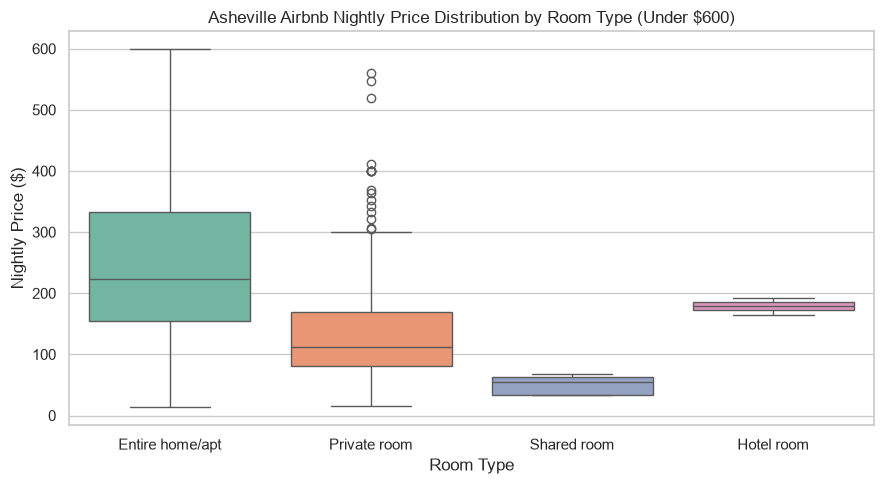

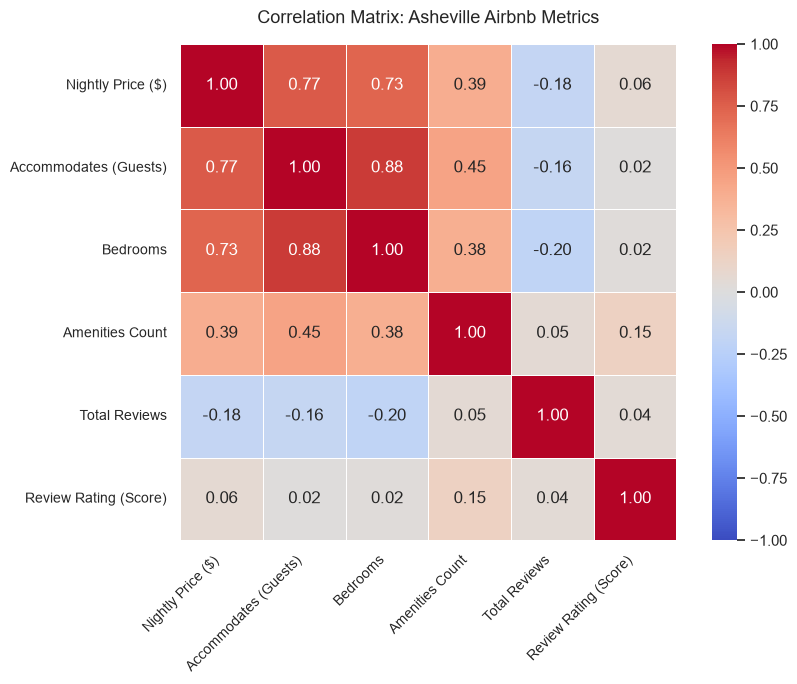


Plots rendered successfully and saved to:
 - asheville_price_by_room_type.png
 - asheville_feature_correlations.png


In [12]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Ensure inline plotting if running inside a Jupyter Notebook
try:
    from IPython import get_ipython

    ipython = get_ipython()
    if ipython is not None:
        ipython.run_line_magic("matplotlib", "inline")
except Exception:
    pass

DATA_DIR = "data/asheville_airbnb"
LISTINGS_PATH = os.path.join(DATA_DIR, "listings.csv.gz")

if not os.path.exists(LISTINGS_PATH):
    raise FileNotFoundError(
        f"'{LISTINGS_PATH}' not found. Make sure you ran the download script first!"
    )

# -------------------------------------------------------------------
# 1. Ingestion
# -------------------------------------------------------------------
print("Loading Asheville detailed listings dataset...")
df_raw = pd.read_csv(LISTINGS_PATH, compression="gzip", low_memory=False)
print(f"Initial dimensions: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")

# -------------------------------------------------------------------
# 2. Data Cleanup & Feature Engineering
# -------------------------------------------------------------------
print("\n--- Cleaning Data ---")
df = df_raw.copy()

# A. Bulletproof Price Parsing (extracts only digits and decimals, ignoring symbols/spaces)
if "price" in df.columns:
    if pd.api.types.is_numeric_dtype(df["price"]):
        df["price_clean"] = df["price"].astype(float)
    else:
        # Extracts digits followed by optional decimal numbers (handles "$120.00", " 120 ", "$1,200.50", etc.)
        df["price_clean"] = (
            df["price"]
            .astype(str)
            .str.extract(r"(\d+(?:,\d+)*(?:\.\d+)?)")[0]
            .str.replace(",", "", regex=False)
            .astype(float)
        )
else:
    raise KeyError("No 'price' column found in the dataset.")

# Verify values exist before filtering
print(f"Non-null price values found: {df['price_clean'].notna().sum()} / {len(df)}")

# B. Convert rate columns (e.g. '98%') to float (0.98)
rate_cols = ["host_response_rate", "host_acceptance_rate"]
for col in rate_cols:
    if col in df.columns:
        if df[col].dtype == object:
            clean_s = (
                df[col]
                .astype(str)
                .str.replace("%", "", regex=False)
                .str.strip()
            )
            df[col + "_clean"] = (
                pd.to_numeric(clean_s, errors="coerce") / 100.0
            )
        else:
            df[col + "_clean"] = pd.to_numeric(df[col], errors="coerce")

# C. Standardize Boolean flags ('t'/'f'/True/False -> 1/0 integers)
bool_cols = ["host_is_superhost", "has_availability", "instant_bookable"]
for col in bool_cols:
    if col in df.columns:
        df[col + "_clean"] = (
            df[col]
            .map({"t": 1, "f": 0, True: 1, False: 0, "1": 1, "0": 0})
            .fillna(0)
            .astype(int)
        )

# D. Extract number of amenities from text list
if "amenities" in df.columns:
    df["amenities_count"] = df["amenities"].apply(
        lambda x: len(eval(x))
        if isinstance(x, str) and x.startswith("[")
        else 0
    )

# E. Select core analytical fields and filter outliers
analysis_cols = [
    "id",
    "name",
    "neighbourhood_cleansed",
    "room_type",
    "accommodates",
    "bedrooms",
    "beds",
    "price_clean",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "review_scores_rating",
    "host_is_superhost_clean",
    "instant_bookable_clean",
    "amenities_count",
]

available_cols = [c for c in analysis_cols if c in df.columns]
df_clean = df[available_cols].copy()

# Filter out null and extreme outlier pricing
initial_len = len(df_clean)
df_clean = df_clean.dropna(subset=["price_clean"])
df_clean = df_clean[
    (df_clean["price_clean"] > 0) & (df_clean["price_clean"] <= 2000)
]
print(f"Dropped {initial_len - len(df_clean)} pricing anomaly/null records.")
print(f"Remaining valid rows for analysis: {len(df_clean)}")

# Impute median values for missing structural and review columns
for col in ["bedrooms", "beds", "reviews_per_month", "review_scores_rating"]:
    if col in df_clean.columns:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)

# Save cleaned dataset
out_dir = "data/cleaned"
os.makedirs(out_dir, exist_ok=True)
cleaned_file = os.path.join(out_dir, "asheville_listings_cleaned.csv")
df_clean.to_csv(cleaned_file, index=False)
print(f"Cleaned data successfully saved to: {cleaned_file}")

# -------------------------------------------------------------------
# 3. Exploratory Data Analysis & Visualizations
# -------------------------------------------------------------------
print("\n--- Exploratory Data Analysis ---")

# Summary Table 1: Breakdown by Room Type
room_summary = (
    df_clean.groupby("room_type")
    .agg(
        listing_count=("id", "count"),
        median_price=("price_clean", "median"),
        mean_price=("price_clean", "mean"),
        avg_rating=("review_scores_rating", "mean"),
    )
    .reset_index()
)
print("\n=== Room Type Summary ===")
print(room_summary.to_string(index=False))

# Summary Table 2: Top Neighborhoods by Volume
top_neighborhoods = (
    df_clean.groupby("neighbourhood_cleansed")
    .agg(
        total_listings=("id", "count"),
        median_price=("price_clean", "median"),
    )
    .sort_values(by="total_listings", ascending=False)
    .head(10)
    .reset_index()
)
print("\n=== Top 10 Neighborhoods by Volume ===")
print(top_neighborhoods.to_string(index=False))

# Configure Seaborn style
sns.set_theme(style="whitegrid")

# Plot 1: Nightly Price Distribution by Room Type
plt.figure(figsize=(9, 5))
plot_subset = df_clean[df_clean["price_clean"] <= 600]

sns.boxplot(
    data=plot_subset,
    x="room_type",
    y="price_clean",
    palette="Set2",
    hue="room_type",
    legend=False,
)
plt.title("Asheville Airbnb Nightly Price Distribution by Room Type (Under $600)")
plt.xlabel("Room Type")
plt.ylabel("Nightly Price ($)")
plt.tight_layout()

# Save figure first, then display inline (avoiding plt.close())
plt.savefig("asheville_price_by_room_type.png", dpi=300)
plt.show()

# Plot 2: Correlation Matrix for Key Numerical Metrics
# Select key numerical features
corr_features = [
    "price_clean",
    "accommodates",
    "bedrooms",
    "amenities_count",
    "number_of_reviews",
    "review_scores_rating",
]

# Mapping dictionary from raw column names to clean display labels
label_mapping = {
    "price_clean": "Nightly Price ($)",
    "accommodates": "Accommodates (Guests)",
    "bedrooms": "Bedrooms",
    "amenities_count": "Amenities Count",
    "number_of_reviews": "Total Reviews",
    "review_scores_rating": "Review Rating (Score)",
}

# Filter to available columns and calculate correlation
available_corr_cols = [c for c in corr_features if c in df_clean.columns]
corr = df_clean[available_corr_cols].corr()

# Rename the index and columns of the correlation matrix for the plot
corr_renamed = corr.rename(index=label_mapping, columns=label_mapping)

# Plot Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_renamed,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    cbar=True,
    linewidths=0.5,
    square=True,
)

plt.title("Correlation Matrix: Asheville Airbnb Metrics", fontsize=13, pad=15)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

# Save and render
plt.savefig("asheville_feature_correlations.png", dpi=300)
plt.show()

print("\nPlots rendered successfully and saved to:")
print(" - asheville_price_by_room_type.png")
print(" - asheville_feature_correlations.png")

In [13]:
print("Raw price column dtype:", df_raw["price"].dtype)
print("\nFirst 10 raw values:")
print(df_raw["price"].head(10))

Raw price column dtype: str

First 10 raw values:
0    $116.00
1     $80.00
2        NaN
3    $104.00
4     $80.29
5    $210.00
6    $171.18
7    $266.00
8    $200.00
9     $76.50
Name: price, dtype: str
